In [1]:
import sys, os
sys.path.insert(0, '../utils')

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from neuron_custom_features import calc_spines_features
from plot_utils import ex_color, inh_color, ei_palette, colors, plot_skeleton_continuous
import skeleton_plot as skelplot
from connectome_types import EM_NEURONS_PATH, NEURONS_PATH
from spines_utils import filter_valid_neuron_w_spines
from utils import load_neurons_table, load_synapses_position_transformed, transform_sk, transform_coord
from tqdm import tqdm
import pickle
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
from mesh_utils import load_full_mesh, extract_dendrite_mesh_via_sk, plot_branch, filter_synapse_position
from connectome_types import DATA_BASE_PATH, NETWORK_NAME
import matplotlib.tri as mtri
from standard_transform import minnie_ds
from matplotlib.gridspec import GridSpecFromSubplotSpec
import matplotlib.colors as mcolors
from sk_load_utils import load_clean_sk, load_col_skeleton_only
from stats_corr import add_reg_line, binned_mul_plot
from figures_utils import add_panel_label, plot_branch_from_image, plot_3d_box
from matplotlib.patches import ConnectionPatch
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter

neurons_df = load_neurons_table(use_column_manual_ct=True)
syn_df = load_synapses_position_transformed()
df, syn_with_tags = calc_spines_features(neurons_df, syn_df)
df, filtered_syn_mat, filtered_bin_mat, filtered_mapping, filtered_reverse_mapping, ex_neurons, inh_neurons = filter_valid_neuron_w_spines(df)


connectome neurons table:  1351
valid neurons w position: 1351
spine table incoming size (4567647, 4)
spine table outgoing size (819832, 4)
neurons: 1351
synapses with tags: 145356


100%|██████████| 1351/1351 [00:14<00:00, 95.62it/s] 


Filtering neurons with valid spine data...
Remaining neurons after filtering: 1298
fixing networks
Filtering: Reducing matrix from 1351 to 1298 neurons.


## Data Loading

In [3]:
neurons_col_data = [
(864691135277186789, '23P', ex_color),
 (864691135875777166, 'BC', inh_color)
]

top_two_neurons = [864691135277186789, 864691135875777166]
top_two_neurons_pos = [neurons_df[neurons_df.root_id == n][['pt_position_xt', 'pt_position_yt']].iloc[0] for n in top_two_neurons]

column_neurons_ids = [neuron_id for neuron_id, _, _ in neurons_col_data]
column_colors = [color for _, _, color in neurons_col_data]

column_skeletons = []
for neuron_id in tqdm(column_neurons_ids):
    column_skeletons.append(load_col_skeleton_only(neuron_id, reset_axon=True, old=True))

100%|██████████| 2/2 [00:00<00:00, 15.52it/s]


## Mesh loading

In [4]:
mesh_path = f"{DATA_BASE_PATH}/{NETWORK_NAME}/meshes"

ex_mesh_full = load_full_mesh(top_two_neurons[0], mesh_path)
inh_mesh_full = load_full_mesh(top_two_neurons[1], mesh_path)

ex_sk_clean = load_clean_sk(top_two_neurons[0])
inh_sk_clean = load_clean_sk(top_two_neurons[1])

Loading mesh for neuron 864691135277186789 from local cache.
Loading mesh for neuron 864691135875777166 from local cache.


In [5]:
ex_mesh_dendrite = extract_dendrite_mesh_via_sk(ex_sk_clean, ex_mesh_full)
vertices_um = minnie_ds.transform_nm.apply(ex_mesh_dendrite.vertices)
ex_mesh_triang = mtri.Triangulation(vertices_um[:, 0], vertices_um[:, 1], ex_mesh_dendrite.faces)

inh_mesh_dendrite = extract_dendrite_mesh_via_sk(inh_sk_clean, inh_mesh_full)
vertices_um = minnie_ds.transform_nm.apply(inh_mesh_dendrite.vertices)
inh_mesh_triang = mtri.Triangulation(vertices_um[:, 0], vertices_um[:, 1], inh_mesh_dendrite.faces)
ex_mesh_full
mesh_triangs = [ex_mesh_triang, inh_mesh_triang]
mesh_dendrites = [ex_mesh_dendrite, inh_mesh_dendrite]

## Plot

In [6]:
plt.rcParams['font.size'] = 13
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['font.family'] = 'Arial'

meanprops={"marker":"o",
           "markerfacecolor":"white", 
           "markeredgecolor":"black",
           "markersize":"5"}

features_small_font_size = 12
err_type = 'std'
n_bins = 8
full_scatter = True

In [9]:
def load_all_incoming_unk_synapses(neuron_id):
    with open(os.path.join(NEURONS_PATH, f'{neuron_id}.pkl'), 'rb') as f:
        full_neuron: Neuron = pickle.load(f)

    all_syn_pos = [(syn.center_position  * np.array([4, 4, 40]) / 1000) for syn in full_neuron.pre_synapses]
    all_syn_center_pos = [syn.center_position for syn in full_neuron.pre_synapses]
    all_syn_sizes = [syn.size for syn in full_neuron.pre_synapses]
    all_syn_pos_df = pd.DataFrame({'pos': all_syn_pos, 'size': all_syn_sizes, 'ctr_pt_position': all_syn_center_pos})
    transform_coord(all_syn_pos_df, s3=True)

    all_syn_pos_df['cell_type'] = 'Unk'
    all_syn_pos_df['position_xt']= all_syn_pos_df.pos.apply(lambda p: p[0])
    all_syn_pos_df['position_yt'] = all_syn_pos_df.pos.apply(lambda p: p[1])
    return all_syn_pos_df

ex_neuron_synapses = load_all_incoming_unk_synapses(top_two_neurons[0])
inh_neuron_synapses = load_all_incoming_unk_synapses(top_two_neurons[1])

In [11]:
branches_fixed_images_dir = f'{DATA_BASE_PATH}/figures/spine_project/fig1_branches'
os.makedirs(branches_fixed_images_dir, exist_ok=True)
branches_images = []
for img_path in sorted(os.listdir(branches_fixed_images_dir)):
    img = plt.imread(os.path.join(branches_fixed_images_dir, img_path))
    branches_images.append(img)

## Synapse EM

In [12]:
ex_branch_syn = filter_synapse_position(xlim=(663, 663+13), ylim=(223,229), syn_df=ex_neuron_synapses)
ex_branch_syn.sort_values('position_xt')

inh_branch_syn = filter_synapse_position(xlim=(702, 702+13), ylim=(380,386), syn_df=inh_neuron_synapses)
inh_branch_syn.sort_values('position_xt').head(3)

,pos,size,ctr_pt_position,cell_type,position_xt,position_yt
2324,"[702.2695143158978, 383.7575553123109, 890.160...",2424.0,"[191904, 179063, 22254]",Unk,702.269514,383.757555
585,"[702.3377053337024, 383.8960254718788, 889.800...",4216.0,"[191924, 179096, 22245]",Unk,702.337705,383.896025
732,"[702.865982955113, 383.5487463986297, 890.3200...",6016.0,"[192048, 178998, 22258]",Unk,702.865983,383.548746


In [13]:
syn_em_image_path = f'{DATA_BASE_PATH}/figures/spine_project/fig1_syn_em_images'

In [14]:
syn_images = []

import imageryclient as ic
from caveclient import CAVEclient
from connectome_types import MATERIALIZATION_VERSION
client = CAVEclient('minnie65_public')
client.materialize.version = MATERIALIZATION_VERSION
img_client = ic.ImageryClient(client=client, image_mip=0, segmentation_mip=0)

# Ex
syn1 = ex_branch_syn.loc[2039][['position_xt', 'position_yt', 'ctr_pt_position']]                            
syn2 = ex_branch_syn.loc[2711][['position_xt', 'position_yt', 'ctr_pt_position']]   
# Inh  
syn3 = inh_branch_syn.loc[1054][['position_xt', 'position_yt', 'ctr_pt_position']]    
syn4 = inh_branch_syn.loc[2735][['position_xt', 'position_yt', 'ctr_pt_position']] 

if len(os.listdir(syn_em_image_path)) == 0:
    bbox_size = (512, 512)

    for syn in tqdm([syn1, syn2, syn3, syn4]):
        print(syn)
        syn_image, _ = img_client.image_and_segmentation_cutout(
            syn.ctr_pt_position,
            split_segmentations=True,
            bbox_size=bbox_size,
            scale_to_bounds=False,
            image_mip=0,
            segmentation_mip=0,
        )
        syn_images.append(syn_image)

    for i, syn_image in enumerate(syn_images):
        np.save(f'{syn_em_image_path}/{i}.npy', syn_image)
else:
    print("Loading synapse EM images from disk...")
    for i in range(4):
        syn_image = np.load(f'{syn_em_image_path}/{i}.npy')
        syn_images.append(syn_image)

if len(os.listdir(branches_fixed_images_dir)):
    print('fixing EM syn position to match new branch images')
    syn1.position_xt = 663.9
    syn1.position_yt = 225.2

    syn2.position_xt = 673
    syn2.position_yt = 226.9

    syn3.position_xt = 703.125
    syn3.position_yt = 383.4

    syn4.position_xt = 713.5
    syn4.position_yt = 382.5

Loading synapse EM images from disk...
fixing EM syn position to match new branch images


Nanometers per pixel: 8 nm/pixel


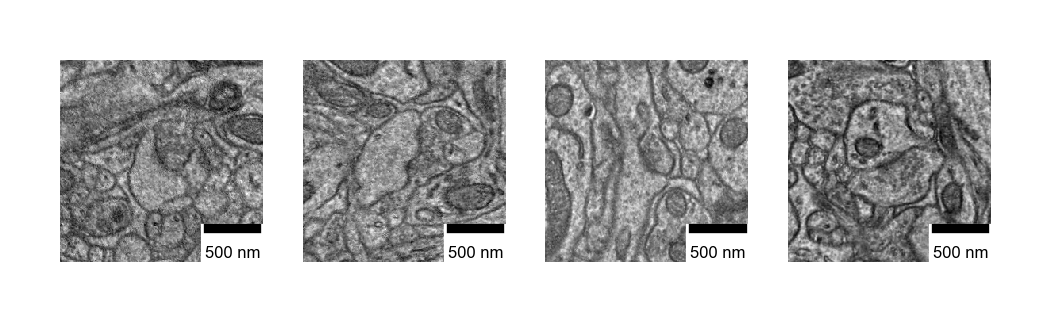

In [16]:
nm_per_pixel = img_client.image_cv.mip_resolution(0)[0]  # 8 nm/pixel
print(f"Nanometers per pixel: {nm_per_pixel} nm/pixel")
target_scale_nm = 500
scalebar_pixels = target_scale_nm / nm_per_pixel

fig, axes = plt.subplots(1, 4, figsize=(0.5 * 4 ,0.5), dpi=600)
for ax, syn_image in zip(axes, syn_images):
    ax.imshow(syn_image, cmap='gray', interpolation='none')

    fontprops = fm.FontProperties(size=2, family='Arial')
    scalebar_em = AnchoredSizeBar(
            transform=ax.transData,
            size=scalebar_pixels,
            label=f'{target_scale_nm} nm',
            loc='lower right',
            pad=0,
            color='black',       # Changes font and scale bar to black
            frameon=True,        # Enables the background box
            size_vertical=1,
            fontproperties=fontprops,
            sep=2,
        )
    scalebar_em.patch.set_facecolor('white')
    scalebar_em.patch.set_alpha(1.0)           # Ensures it is fully opaque
    scalebar_em.patch.set_edgecolor('white')
    ax.add_artist(scalebar_em)

for ax in axes:
    ax.axis('off')
# fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

In [17]:
# removing a *single* outlier with a very high number of incoming synapses
# doesnt effect the overall trends, but makes the plot more readable
print('before:', df.shape)
df = df[df.ds_num_of_incoming_synapses < 25000].copy()
print('after:', df.shape)

(1297, 110)

C:\Users\dean\AppData\Local\Temp\ipykernel_25596\1803831024.py:149: MatplotlibDeprecationWarning: Since Matplotlib 3.10 indicate_inset_[zoom] returns a single InsetIndicator artist with a rectangle property and a connectors property.  From 3.12 it will no longer be possible to unpack the return value into two elements.
  rect, connectors = ax_mid.indicate_inset_zoom(


inh - spines
R=0.55 R^2: 0.30 slope: 0.20 intercept: -0.01, p=p=1.1e-13
inh - shafts
R=0.93 R^2: 0.87 slope: 0.77 intercept: 0.02, p=p=1.8e-72
ex - spines
R=0.94 R^2: 0.89 slope: 0.81 intercept: -0.10, p=p=0.0e+00
ex - shafts
R=0.51 R^2: 0.26 slope: 0.17 intercept: 0.09, p=p=9.9e-76


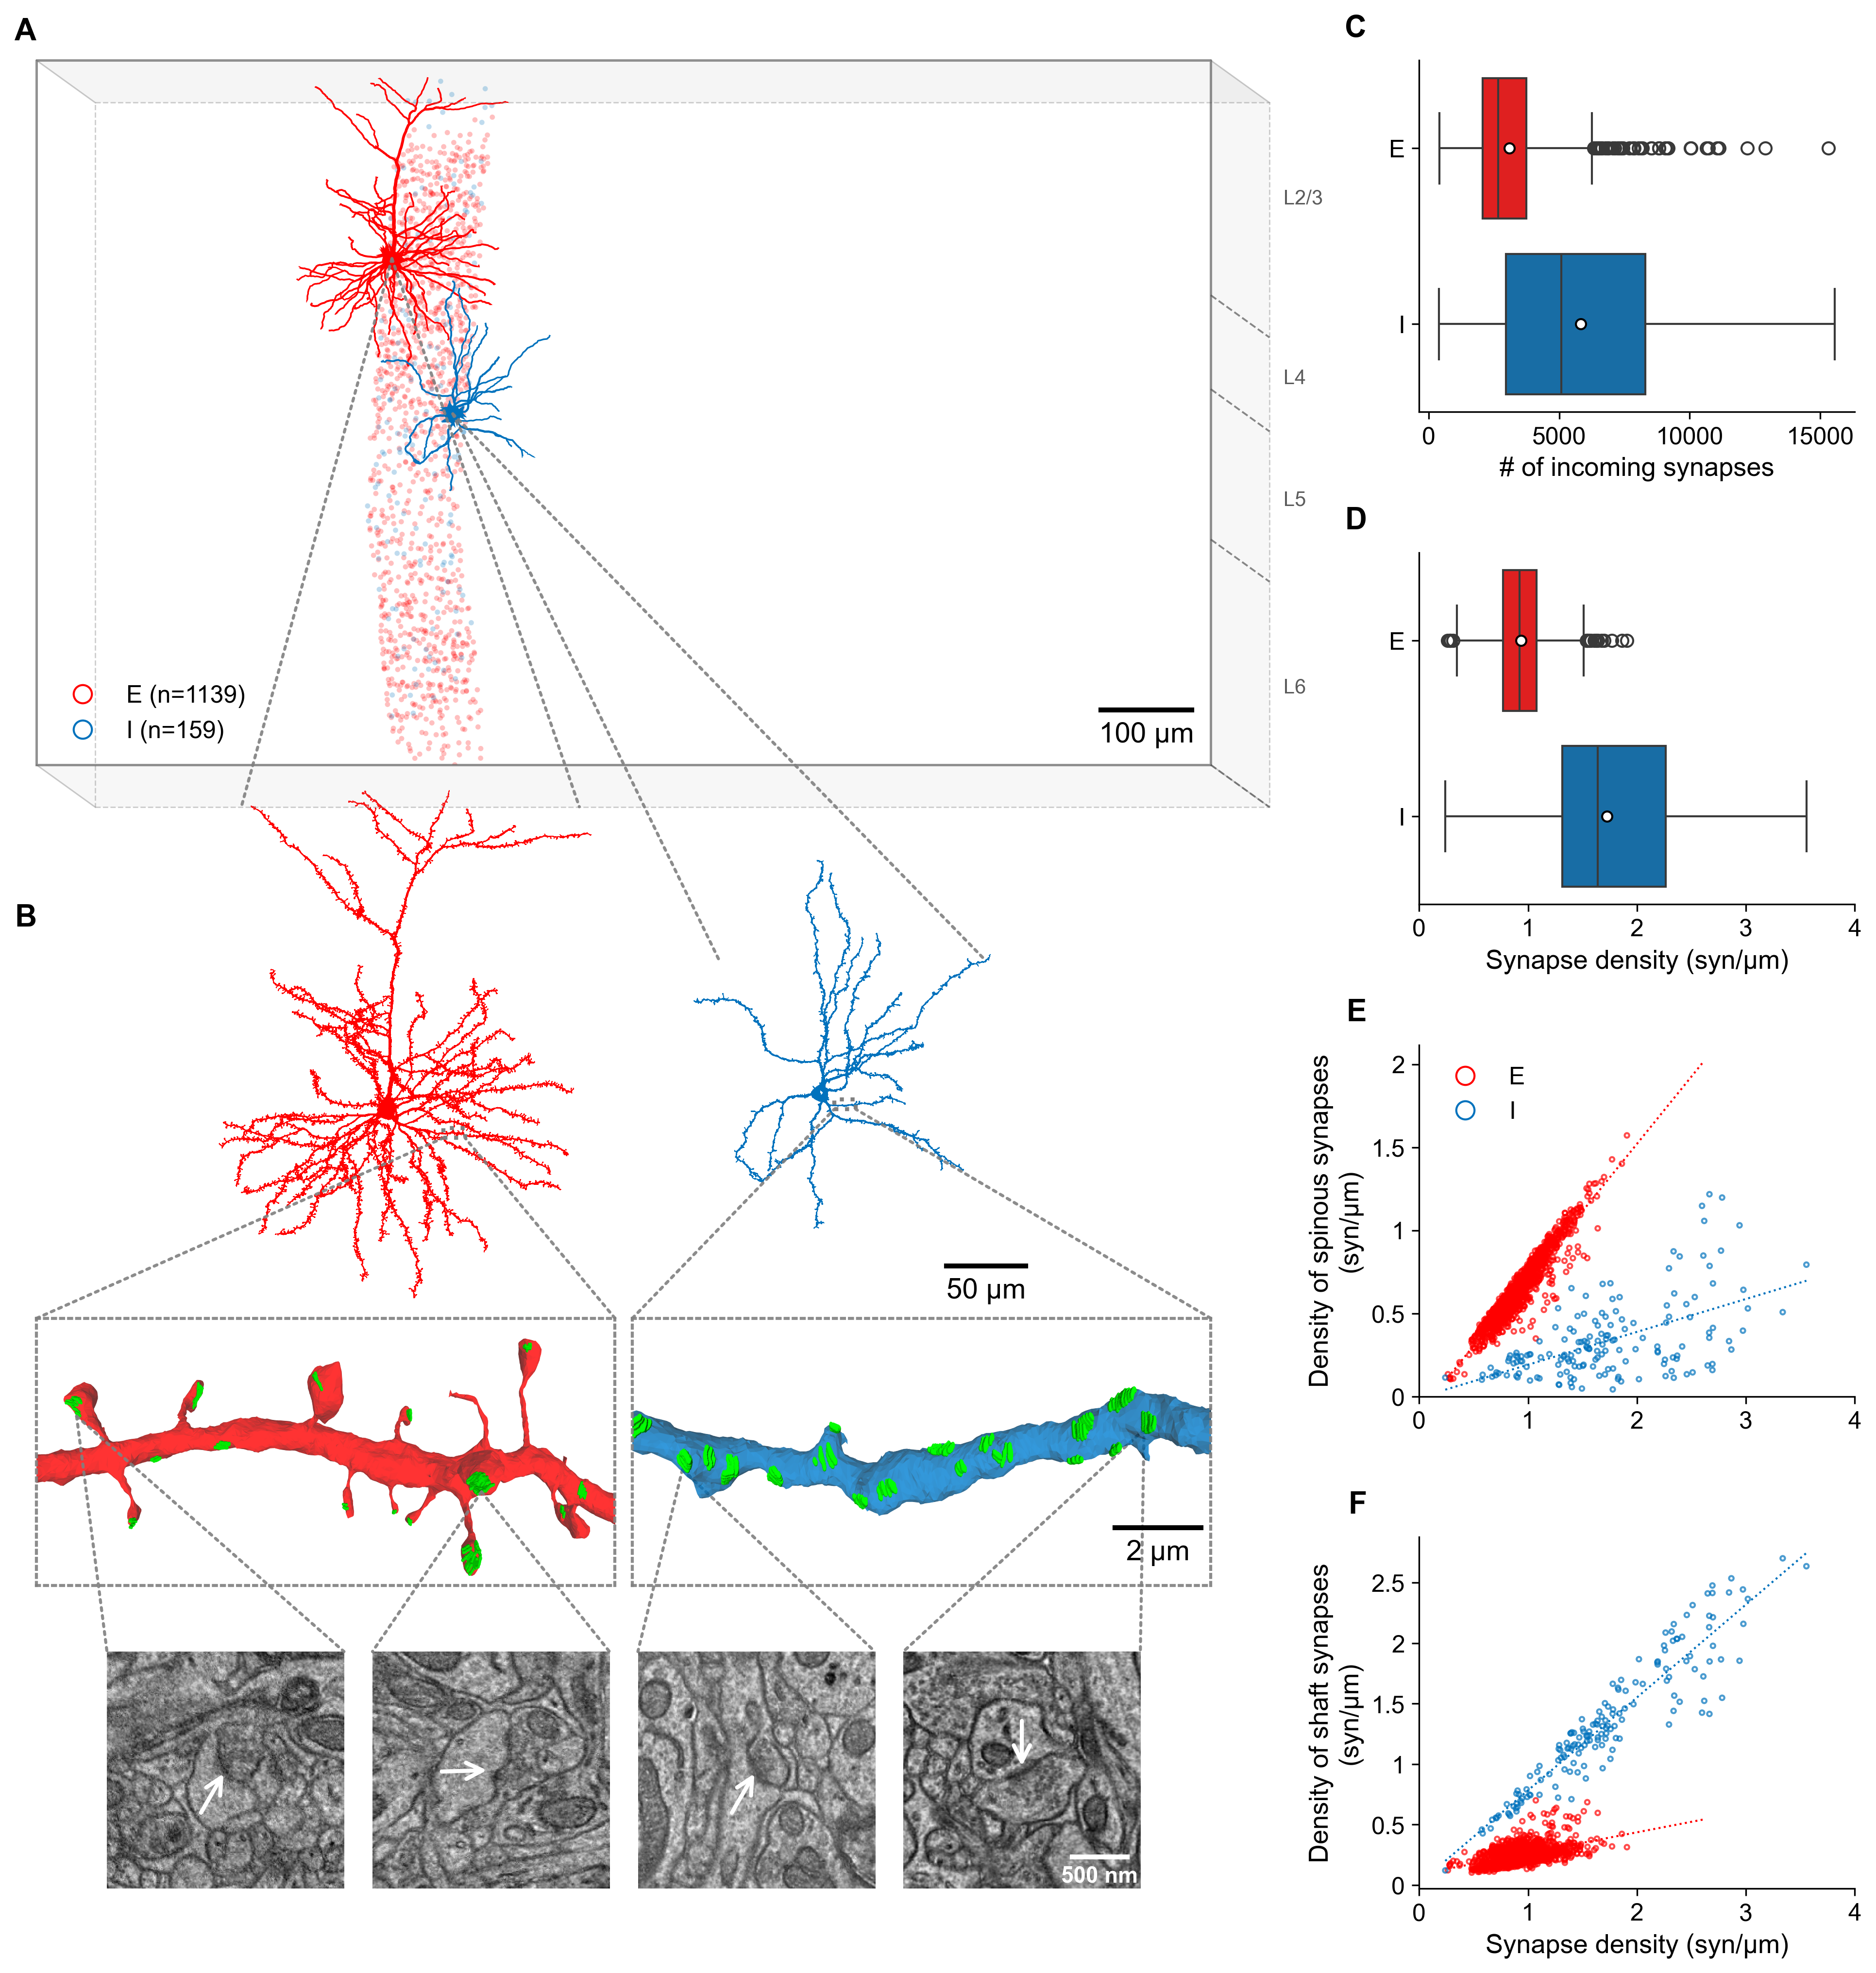

In [18]:
def ei_legend(with_numbers=False):
    if with_numbers:
        e_label = f'E (n={len(ex_neurons)})'
        i_label = f'I (n={len(inh_neurons)})'
    else:
        e_label = 'E'
        i_label = 'I'

    legend_handles = [
        Line2D([0], [0], marker='o', linestyle='none', markeredgecolor=ei_palette['E'], 
                markerfacecolor='none', markersize=9, label=e_label),
        Line2D([0], [0], marker='o', linestyle='none', markeredgecolor=ei_palette['I'], 
                markerfacecolor='none', markersize=9, label=i_label)
    ]
    return legend_handles

# ==========================================
# 1. MAIN FIGURE & INDEPENDENT GRIDSPECS
# ==========================================
fig = plt.figure(figsize=(13, 23), dpi=300)

# We use two separate top-level GridSpecs instead of a master nested one.
# This allows us to dynamically shrink the right side's boundaries later.
gs_left = fig.add_gridspec(
    nrows=7, ncols=2, 
    left=0.02, right=0.64,  # Ends at 55% of the figure width
    hspace=0, wspace=0,
    height_ratios=[2.00, 0.00, 1.40, -1, 1.25, -0.5, 0.70]
)

# Right Side Setup
gs_right = fig.add_gridspec(
    nrows=4, ncols=1, 
    left=0.75, right=0.98,  # Starts at 68% (creates a 13% gap) and ends at 96% (narrowing the width)
    hspace=0.4
)
# ==========================================
# 2. LEFT SIDE PLOTTING
# ==========================================
# Top Panel
ax_top = fig.add_subplot(gs_left[0, :])

sns.scatterplot(data=neurons_df, x='pt_position_xt', y='pt_position_yt', hue='clf_type', palette=ei_palette, ax=ax_top, s=7, alpha=0.25)
# ax_top.get_legend().remove()
ax_top.legend(handles=ei_legend(with_numbers=True), title='', frameon=False, loc='lower left')


for neuron_id, sk, color in zip(column_neurons_ids, column_skeletons, column_colors):
    if neuron_id in top_two_neurons:
        line_width = 3
        alpha = 1
    else:
        line_width = 1.4 if color == inh_color else 1
        alpha = 1 if color == inh_color else 0.65
    ignore_soma = False if neuron_id in top_two_neurons else True
    plot_skeleton_continuous(ax=ax_top, sk=sk, lw=line_width, alpha=alpha, color=color, ignore_vertex_zero=ignore_soma)

ax_top.set_title('')
ax_top.set_ylim(750, 0)
ax_top.set_xlim(250, 1500)
ax_top.set_aspect('equal')
ax_top.set_anchor('S')

for spine in ax_top.spines.values():
    spine.set_visible(False)
ax_top.tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)
ax_top.set_xlabel('')
ax_top.set_ylabel('')

# Middle Panels
gs_mid = GridSpecFromSubplotSpec(1, 4, subplot_spec=gs_left[2, :], 
                                 width_ratios=[1, 3, 3, 1], wspace=0.1)
ax_ml = fig.add_subplot(gs_mid[1])
ax_mr = fig.add_subplot(gs_mid[2])

axes_middle = [ax_ml, ax_mr]
ax_ml.set_anchor('NE')  
ax_mr.set_anchor('NW')  

for ax_mid, mesh_triang, mesh_dendrite,  color in zip(axes_middle, mesh_triangs, mesh_dendrites, [ex_color, inh_color]):
    ax_mid.triplot(mesh_triang, color=color, alpha=1, lw=0.1)
    ax_mid.set_aspect('equal')
    ax_mid.invert_yaxis()
    for spine in ax_mid.spines.values():
        spine.set_visible(False)
    ax_mid.tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)

lims = []
for ax_mid in axes_middle:
    xlim = ax_mid.get_xlim()
    ylim = ax_mid.get_ylim()
    lims.append({
        'x_center': sum(xlim) / 2,
        'y_center': sum(ylim) / 2,
        'x_span': abs(xlim[1] - xlim[0]),
        'y_span': abs(ylim[1] - ylim[0]),
        'y_inverted': ylim[0] > ylim[1] 
    })

max_x_span = max(lim['x_span'] for lim in lims)
max_y_span = max(lim['y_span'] for lim in lims)

pad_factor = 1.0
final_x_span = max_x_span * pad_factor
final_y_span = max_y_span * pad_factor

for ax_mid, lim in zip(axes_middle, lims):
    ax_mid.set_xlim(lim['x_center'] - final_x_span / 2, lim['x_center'] + final_x_span / 2)
    if lim['y_inverted']:
        ax_mid.set_ylim(lim['y_center'] + final_y_span / 2, lim['y_center'] - final_y_span / 2)
    else:
        ax_mid.set_ylim(lim['y_center'] - final_y_span / 2, lim['y_center'] + final_y_span / 2)

# Bottom Panels
gs_bottom = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_left[4, :], wspace=0.03)
ax_bl = fig.add_subplot(gs_bottom[0])
ax_br = fig.add_subplot(gs_bottom[1])

if len(os.listdir(branches_fixed_images_dir)) == 0:
    plot_branch(xlim=(663, 663+13), ylim=(223, 229),
                mesh=ex_mesh_dendrite, mesh_triang=ex_mesh_triang,
                mesh_color=ex_color, syn_df=ex_neuron_synapses,
                plot_shaded_mesh=True, ax=ax_bl, add_scale_bar=False)
    plot_branch(xlim=(702, 702+13), ylim=(380, 386),
                mesh=inh_mesh_dendrite, mesh_triang=inh_mesh_triang,
                mesh_color=inh_color, syn_df=inh_neuron_synapses,
                plot_shaded_mesh=True, ax=ax_br, add_scale_bar=False)
else:
    plot_branch_from_image(ax_bl, branch_idx=0, branches_images=branches_images, original_xlim=(663, 663+13), original_ylim=(223, 229),
                       x_trim=0, y_trim=0)
    plot_branch_from_image(ax_br, branch_idx=1, branches_images=branches_images, original_xlim=(702, 702+13), original_ylim=(380, 386),
                       x_trim=0, y_trim=0)

zoomed_color = 'grey'
zoomed_alpha = 0.9
zoomed_lw = 1.5
zoomed_style = ':'

for ax_bot in [ax_bl, ax_br]:
    for spine in ax_bot.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(zoomed_lw)
        spine.set_color(zoomed_color)
        spine.set_alpha(zoomed_alpha)
        spine.set_linestyle(zoomed_style)

# Connections Mid -> Bottom
for ax_mid, ax_bot in zip([ax_ml, ax_mr], [ax_bl, ax_br]):
    rect, connectors = ax_mid.indicate_inset_zoom(
        ax_bot, edgecolor=zoomed_color, linewidth=zoomed_lw,
        linestyle=zoomed_style, alpha=zoomed_alpha
    )
    rect.set_visible(True)
    rect.set_linestyle(zoomed_style)
    rect.set_linewidth(zoomed_lw+0.5)
    rect.set_alpha(1)
    rect.set_edgecolor(zoomed_color)
    rect.set_zorder(10)

    connectors[0].set_visible(False)
    connectors[1].set_visible(True)
    connectors[1].set_zorder(10)
    connectors[2].set_visible(False)
    connectors[3].set_visible(True)
    connectors[3].set_zorder(10)

# Connections Top -> Mid
for neuron_pos, ax_mid, y_coord_offset, corner_start in zip(top_two_neurons_pos, [ax_ml, ax_mr], [0.925, 0.65], [[0.1,0.925], [0.2,0.85]]):
    xy_top = (neuron_pos['pt_position_xt'], neuron_pos['pt_position_yt'])
    for corner_x in corner_start: 
        con = ConnectionPatch(
            xyA=xy_top, coordsA=ax_top.transData,
            xyB=(corner_x, y_coord_offset), coordsB=ax_mid.transAxes,
            color=zoomed_color, linewidth=zoomed_lw, linestyle=zoomed_style,
            alpha=zoomed_alpha, arrowstyle='-', zorder=15
        )
        fig.add_artist(con)

# EM Synapse Row
gs_em_outer = GridSpecFromSubplotSpec(
    1, 3, subplot_spec=gs_left[6, :],
    width_ratios=[0.06, 0.88, 0.06],  # wider side pads → narrower EM block
    wspace=0
)

gs_em = GridSpecFromSubplotSpec(1, 4, subplot_spec=gs_em_outer[1], wspace=0.12)  # more gap between images
ax_em = [fig.add_subplot(gs_em[i]) for i in range(4)]

nm_per_pixel = img_client.image_cv.mip_resolution(0)[0]
target_scale_nm = 500
scalebar_pixels_em = target_scale_nm / nm_per_pixel

fontprops_em = fm.FontProperties(size=11, family='Arial', weight='bold')
for i, (ax, syn_image) in enumerate(zip(ax_em, syn_images)):
    ax.imshow(syn_image, cmap='gray', interpolation='none')
    if i == 3:
        scalebar_em = AnchoredSizeBar(
            transform=ax.transData, size=scalebar_pixels_em,
            label=f'{target_scale_nm} nm', loc='lower right',
            pad=0, color='white', frameon=False, size_vertical=3,
            fontproperties=fontprops_em, sep=3.5,
        )
        ax.add_artist(scalebar_em)
    ax.axis('off')

# ── White arrows on EM synapse images ───────────────────────────────────────
# tail = arrow start; head = arrowhead tip pointing toward the synapse.
# Coordinates are image pixels: (0,0)=top-left, (511,511)=bottom-right.
# Adjust tail_x/tail_y and head_x/head_y per image to reposition;
# the direction (angle) is set by the vector from tail to head.
em_arrow_params = [
    {'tail_x': 98.8,  'tail_y': 177.3, 'head_x': 127.5, 'head_y': 127.5},  # image 0
    {'tail_x': 70.0,  'tail_y': 129.2, 'head_x': 127.5, 'head_y': 127.5},  # image 1
    {'tail_x': 98.8, 'tail_y': 177.3, 'head_x': 127.5, 'head_y': 127.5},  # image 2
    {'tail_x': 127.5,  'tail_y': 70,  'head_x': 127.5, 'head_y': 127.5},  # image 3
]
em_arrow_color = 'white'
em_arrow_lw = 2.0         # line width of the arrow shaft
em_arrow_head_size = 20   # mutation_scale: controls arrowhead size

for ax, ap in zip(ax_em, em_arrow_params):
    ax.annotate('',
        xy=(ap["head_x"], ap["head_y"]),
        xytext=(ap["tail_x"], ap["tail_y"]),
        xycoords='data', textcoords='data',
        arrowprops=dict(
            arrowstyle='->', color=em_arrow_color,
            lw=em_arrow_lw, mutation_scale=em_arrow_head_size,
        ),
        zorder=20,
    )

# Zoom connections Bottom -> EM
syn_positions = [
    (syn1['position_xt'], syn1['position_yt'], ax_bl),
    (syn2['position_xt'], syn2['position_yt'], ax_bl),
    (syn3['position_xt'], syn3['position_yt'], ax_br),
    (syn4['position_xt'], syn4['position_yt'], ax_br),
]

for (syn_x, syn_y, ax_src), ax_dst in zip(syn_positions, ax_em):
    for corner_x in [0.0, 1.0]:
        con = ConnectionPatch(
            xyA=(syn_x, syn_y),   coordsA=ax_src.transData,
            xyB=(corner_x, 1.0),  coordsB=ax_dst.transAxes,
            color=zoomed_color, linewidth=zoomed_lw,
            linestyle=zoomed_style, alpha=zoomed_alpha,
            arrowstyle='-', zorder=15,
        )
        fig.add_artist(con)

plot_3d_box(ax_top, layer_fontsize=10)


# ==========================================
# 3. RIGHT SIDE LAYOUT & PLOTTING
# ==========================================
axes = [fig.add_subplot(gs_right[i]) for i in range(4)]
axes[3].sharex(axes[2])

sns.boxplot(data=df, y='clf_type', x='ds_num_of_incoming_synapses', palette=ei_palette, 
            hue='clf_type', ax=axes[0], showfliers=True, showmeans=True, meanprops=meanprops)
axes[0].set_xlabel('# of incoming synapses')

sns.boxplot(data=df, y='clf_type', x='ds_incoming_synapses_density', palette=ei_palette, 
            hue='clf_type', ax=axes[1], showfliers=True, showmeans=True, meanprops=meanprops)
axes[1].set_xlabel('Synapse density (syn/μm)')
axes[1].set_xlim((0,4))

if full_scatter:
    point_colors = df['clf_type'].map(ei_palette)
    axes[2].scatter(
        x=df['ds_incoming_synapses_density'], y=df['ds_spine_density'], 
        edgecolors=point_colors, facecolors='none', s=5, alpha=0.7
    )
    axes[3].scatter(
        x=df['ds_incoming_synapses_density'], y=df['ds_shaft_density'], 
        edgecolors=point_colors, facecolors='none', s=5, alpha=0.7
    )

    axes[2].legend(handles=ei_legend(with_numbers=False), title='', frameon=False)
    
    print('inh - spines')
    add_reg_line(inh_neurons['ds_incoming_synapses_density'], inh_neurons['ds_spine_density'], ax=axes[2], color=inh_color)
    print('inh - shafts')
    add_reg_line(inh_neurons['ds_incoming_synapses_density'], inh_neurons['ds_shaft_density'], ax=axes[3], color=inh_color)
    print('ex - spines')
    add_reg_line(ex_neurons['ds_incoming_synapses_density'], ex_neurons['ds_spine_density'], ax=axes[2], color=ex_color)
    print('ex - shafts')
    add_reg_line(ex_neurons['ds_incoming_synapses_density'], ex_neurons['ds_shaft_density'], ax=axes[3], color=ex_color)
    
    for ax in [axes[2], axes[3]]:
        if ax.get_legend() is not None:
            sns.move_legend(ax, loc='upper left', title='', frameon=False)
        ax.yaxis.set_major_formatter(FormatStrFormatter('%g'))
        ax.xaxis.set_major_formatter(FormatStrFormatter('%g'))
else:
    binned_mul_plot(
        dfs=[ex_neurons, inh_neurons], names=['Ex Neurons', 'Inh Neurons'],
        y_list=['ds_spine_density', 'ds_spine_density'], x_list=['ds_incoming_synapses_density', 'ds_incoming_synapses_density'],
        cmap=[ex_color, inh_color], n_bins=n_bins, bin_amount=[0, 1],
        bin_amount_text_size=10, error_type=err_type, add_reg_line=True,
        add_reg_text=True, add_r_to_legend=False, ax=axes[2]
    )

    binned_mul_plot(
        dfs=[ex_neurons, inh_neurons], names=['Ex Neurons', 'Inh Neurons'],
        x_list=['ds_incoming_synapses_density', 'ds_incoming_synapses_density'], y_list=['ds_shaft_density', 'ds_shaft_density'],
        cmap=[ex_color, inh_color], n_bins=n_bins, bin_amount=[],
        bin_amount_text_size=10, error_type=err_type, add_reg_line=True,
        add_reg_text=True, add_r_to_legend=False, ax=axes[3]
    )

axes[2].set_ylabel('Density of spinous synapses\n(syn/μm)')
axes[3].set_ylabel('Density of shaft synapses\n(syn/μm)')
axes[3].set_xlabel('Synapse density (syn/μm)')

# Formatting Right Side
for ax in [axes[2]]:
    ax.set_xlim((0,4))
    ax.set_ylim(bottom=0)

for ax in [axes[0], axes[1]]:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    ax.set_ylabel('')

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# ==========================================
# 4. PERFECT HEIGHT MATCHING
# ==========================================
fig.canvas.draw()

# Extract the *actual drawn* bounding box of the highest left panel
true_top = ax_top.get_window_extent().transformed(fig.transFigure.inverted()).y1

# Extract the *actual drawn* bounding box of the lowest left panels (EM images)
true_bottom = min([ax.get_window_extent().transformed(fig.transFigure.inverted()).y0 for ax in ax_em])

# Dynamically update the Right Side's GridSpec to lock onto these exact limits
gs_right.update(top=true_top, bottom=true_bottom)


# ==========================================
# 5. FINAL DRAW AND SCALE BARS 
# ==========================================
# Redraw canvas to update positions before rendering scale bars
fig.canvas.draw()

def data_units_per_point(ax, axis='y'):
    bbox = ax.get_window_extent(renderer=fig.canvas.get_renderer())
    points_per_pixel = 72 / fig.dpi
    if axis == 'y':
        pixel_span = bbox.height
        data_span = abs(np.diff(ax.get_ylim()))[0]
    else:
        pixel_span = bbox.width
        data_span = abs(np.diff(ax.get_xlim()))[0]
    return (data_span / pixel_span) * (1 / points_per_pixel)

target_height_pts = 1.5 

sv_top    = data_units_per_point(ax_top) * target_height_pts
sv_mid    = data_units_per_point(ax_mr)  * target_height_pts
sv_bottom = data_units_per_point(ax_br)  * target_height_pts

fontprops = fm.FontProperties(size=14, family='Arial')

scalebar_top = AnchoredSizeBar(
    transform=ax_top.transData, size=100, label='100 µm', sep=5,
    loc='lower right', pad=0.5, color='black', frameon=False,
    size_vertical=sv_top, fontproperties=fontprops,
)
ax_top.add_artist(scalebar_top)

scalebar_mid = AnchoredSizeBar(transform=ax_mr.transData, size=50, label='50 µm', sep=5,
                               loc='lower right', pad=0.3, borderpad=0.4,
                               color='black', frameon=False,
                               size_vertical=sv_mid, fontproperties=fontprops)
ax_mr.add_artist(scalebar_mid)

scalebar_bottom = AnchoredSizeBar(transform=ax_br.transData, size=2, label='2 µm', sep=5,
                               loc='lower right', pad=0.3, borderpad=0.4,
                               color='black', frameon=False,
                               size_vertical=sv_bottom, fontproperties=fontprops, bbox_to_anchor=(1.02, 0.0),
                               bbox_transform=ax_br.transAxes)
scalebar_bottom.set_zorder(10)
ax_br.add_artist(scalebar_bottom)
ax_top.set_zorder(10)
ax_ml.set_zorder(1)
ax_mr.set_zorder(1)
ax_bl.set_zorder(5)
ax_br.set_zorder(20)
ax_bl.patch.set_alpha(0)
ax_br.patch.set_alpha(0)

# ==========================================
# 6. PANEL LETTERS (A-F)
# ==========================================
add_panel_label(ax_top, 'A', xy=(-0.0, 1.02), fontsize=15)
add_panel_label(fig, 'B', xy=(0.02, 0.43), fontsize=15)
add_panel_label(axes[0], 'C', xy=(-0.12, 1.05), fontsize=15)
add_panel_label(axes[1], 'D', xy=(-0.12, 1.05), fontsize=15)
add_panel_label(axes[2], 'E', xy=(-0.12, 1.05), fontsize=15)
add_panel_label(axes[3], 'F', xy=(-0.12, 1.05), fontsize=15)

# heavy figure
plt.savefig('fig1_300.png', transparent=False, bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()